## Pretrained Transformer Model


In [3]:
pip install datasets


In [4]:
import pandas as pd
from datasets import Dataset
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    Trainer,
    TrainingArguments,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers.trainer_callback import TrainerCallback


In [5]:
import pandas as pd

# Load the dataset
file_path = "spa.txt"
data = []

# Read the file line by line
with open(file_path, "r", encoding="utf-8") as file:
    for line in file:
        # Split the line into English and Spanish parts
        parts = line.split("\t")
        if len(parts) >= 2:  # Ensure the line has both English and Spanish
            data.append({"english": parts[0], "spanish": parts[1]})

# Convert to DataFrame
df = pd.DataFrame(data)

# Inspect the dataset
print(df.head())


                         english                                     spanish
0  I'm fed up with your stories!                ¡Estoy harto de sus cuentos!
1  I'm fed up with your stories!  ¡Estoy hasta las narices de tus historias!
2  I'm feeling pretty confident.                     Me siento muy confiado.
3  I'm fine. How about you guys?                    Estoy bien, ¿y vosotros?
4  I'm getting better every day.                       Estoy cada día mejor.


In [6]:
# Remove unnecessary whitespace and special characters
df["english"] = df["english"].str.strip().replace(r"[^a-zA-Z\s]", "", regex=True)
df["spanish"] = df["spanish"].str.strip().replace(r"[^a-zA-Z\s]", "", regex=True)

# Check for null or empty entries
df.dropna(inplace=True)
df = df[df["english"] != ""]
df = df[df["spanish"] != ""]

# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(df)



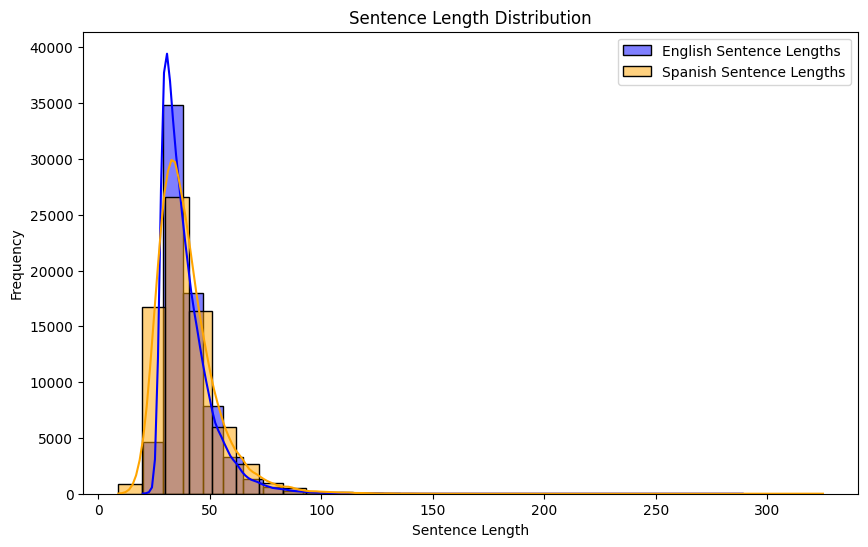

In [7]:
# Plot data distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["english"].str.len(), kde=True, bins=30, color="blue", label="English Sentence Lengths")
sns.histplot(df["spanish"].str.len(), kde=True, bins=30, color="orange", label="Spanish Sentence Lengths")
plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [8]:
from transformers import GPT2Tokenizer

# Load the GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Add padding token if missing
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Tokenize the dataset
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["english"],  # Tokenize English sentences
        padding="max_length",
        truncation=True,
        max_length=50,
    )
    tokenized["labels"] = tokenized["input_ids"].copy()  # Use input_ids as labels
    return tokenized

# Tokenize dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/71100 [00:00<?, ? examples/s]

In [9]:
# Split into train and validation sets
train_test_split = tokenized_dataset.train_test_split(test_size=0.5)
train_dataset = train_test_split["train"]
val_dataset = train_test_split["test"]



In [10]:
# 4. Load the GPT-2 Model
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tokenizer))



Embedding(50257, 768)

In [11]:
# 5. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
)


In [12]:
# 6. Custom Callback for Loss Visualization
class LossPlotCallback(TrainerCallback):
    def __init__(self):
        self.training_loss = []
        self.validation_loss = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if "loss" in logs:
            self.training_loss.append(logs["loss"])
        if "eval_loss" in logs:
            self.validation_loss.append(logs["eval_loss"])

loss_callback = LossPlotCallback()


In [33]:
# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,  # Required for processing inputs and outputs
)


<ipython-input-33-62609f6829f2>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [30]:
# 7. Train the Model
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.417500,0.458382
2,0.416200,0.457189
3,0.402100,0.457183


TrainOutput(global_step=1668, training_loss=0.4008112279631251, metrics={'train_runtime': 2085.8821, 'train_samples_per_second': 51.129, 'train_steps_per_second': 0.8, 'total_flos': 2721366720000000.0, 'train_loss': 0.4008112279631251, 'epoch': 3.0})

In [31]:
# 8. Save the Fine-Tuned Model
model.save_pretrained("./fine_tuned_gpt2")
tokenizer.save_pretrained("./fine_tuned_gpt2")


('./fine_tuned_gpt2/tokenizer_config.json',
 './fine_tuned_gpt2/special_tokens_map.json',
 './fine_tuned_gpt2/vocab.json',
 './fine_tuned_gpt2/merges.txt',
 './fine_tuned_gpt2/added_tokens.json')

In [35]:
# 9. Generate Text Using the Fine-Tuned Model
from transformers import pipeline

# Load the fine-tuned model
generator = pipeline("text-generation", model="./fine_tuned_gpt2", tokenizer=tokenizer)

# Generate text
input_text = " cat is "
generated_text = generator(input_text, max_length=50, num_return_sequences=1)
print(generated_text[0]["generated_text"])

Device set to use cuda:0


 cat is  centimeters in length
